In [2]:
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from pathlib import Path
from enum import Enum
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
TRACE_DIR = "../input/synthetic_traces"
all_trace_folders = glob.glob(os.path.join(TRACE_DIR, "*"))
seeds = []
for folder in all_trace_folders:
    if os.path.isdir(folder) and os.path.exists(os.path.join(folder, "tasks.parquet")):
        seeds.append(folder)

print(f" loaded {len(seeds)} unique seeds.")
if len(seeds) == 0:
    raise ValueError("No valid traces found")

 loaded 256 unique seeds.


 Generate the Workloads from sysnthetic data

In [40]:
n_values = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

for task_count in n_values:
    print(f"Generating Workloads for n = {task_count}...")
    final_tasks = []
    final_fragments = []
    rng = np.random.default_rng(seed=42)
    submission_time = int(
        pd.to_datetime("2022-07-01 12:00:00", utc=True).timestamp() * 1000
    )

    shift_size = 10000

    for i in range(0, task_count):
        if task_count >= 10000 and i % 1000 == 0:
            print(f"  Processed {i}/{task_count}...")

        seed = rng.choice(seeds)
        tasks = pd.read_parquet(f"{seed}/tasks.parquet")
        fragments = pd.read_parquet(f"{seed}/fragments.parquet")

        # Shift Logic
        tasks["id"] += i * shift_size
        tasks["parents"] += i * shift_size
        tasks["children"] += i * shift_size
        fragments["id"] += i * shift_size

        # Submission Time Logic
        n_second_offset = rng.integers(1, 10) * 1000
        submission_time += n_second_offset
        tasks["submission_time"] = submission_time
        tasks["deadline"] = tasks["submission_time"] + 100

        final_tasks.append(tasks.copy())
        final_fragments.append(fragments.copy())
    final_tasks_df = pd.concat(final_tasks).reset_index(drop=True)
    final_fragments_df = pd.concat(final_fragments).reset_index(drop=True)
    
    output_dir = f"scaling_workloads/workload_{task_count}"
    os.makedirs(output_dir, exist_ok=True)

    final_tasks_df.to_parquet(f"{output_dir}/tasks.parquet")
    final_fragments_df.to_parquet(f"{output_dir}/fragments.parquet")
    
    print(f"Saved workload_{task_count}")



Generating Workloads for n = 70...
  Concatenating 70 dataframes (this may take a moment)...
✅ Saved workload_70
Generating Workloads for n = 80...
  Concatenating 80 dataframes (this may take a moment)...
✅ Saved workload_80
Generating Workloads for n = 90...
  Concatenating 90 dataframes (this may take a moment)...
✅ Saved workload_90


In [4]:
class SchedulerEnum(Enum):
    DEFAULT_SCHEDULER = 0
    WORKFLOW_AWARE_SCHEDULER = 1



 Running scenario: 0 
 Starting seed: 0 


Simulating...   0% [                                       ] 0/2 (0:00:00 / ?) 

Creating ComputeScheduler: Random with 100 hosts
12:22:53.142 [WARN ] org.opendc.compute.simulator.telemetry.ComputeMetricReader - 
					Metrics after 24 hours:
						Tasks Total: 754
						Tasks Active: 7
						Tasks Pending: 0
						Tasks Completed: 698
						Tasks Terminated: 0

12:22:53.170 [WARN ] org.opendc.compute.simulator.telemetry.ComputeMetricReader - 
					Metrics after 48 hours:
						Tasks Total: 754
						Tasks Active: 3
						Tasks Pending: 0
						Tasks Completed: 728
						Tasks Terminated: 0



 Running scenario: 1 
 Starting seed: 0 
Creating ComputeScheduler: WorkflowAware with 100 hosts
12:22:53.960 [WARN ] org.opendc.compute.simulator.telemetry.ComputeMetricReader - 
					Metrics after 24 hours:
						Tasks Total: 754
						Tasks Active: 7
						Tasks Pending: 0
						Tasks Completed: 698
						Tasks Terminated: 0

12:22:53.975 [WARN ] org.opendc.compute.simulator.telemetry.ComputeMetricReader - 
					Metrics after 48 hours:
						Tasks Total: 754
						Tasks Act

Simulating... 100% [=================================] 2/2 (0:00:03 / 0:00:00) 




 Running scenario: 0 
 Starting seed: 0 


...

Creating ComputeScheduler: Random with 10 hosts
12:24:20.663 [WARN ] org.opendc.compute.simulator.telemetry.ComputeMetricReader - 
					Metrics after 24 hours:
						Tasks Total: 9726
						Tasks Active: 59
						Tasks Pending: 1562
						Tasks Completed: 1065
						Tasks Terminated: 0

12:24:21.247 [WARN ] org.opendc.compute.simulator.telemetry.ComputeMetricReader - 
					Metrics after 48 hours:
						Tasks Total: 9726
						Tasks Active: 51
						Tasks Pending: 1165
						Tasks Completed: 5414
						Tasks Terminated: 0

12:24:21.754 [WARN ] org.opendc.compute.simulator.telemetry.ComputeMetricReader - 
					Metrics after 72 hours:
						Tasks Total: 9726
						Tasks Active: 60
						Tasks Pending: 1516
						Tasks Completed: 6362
						Tasks Terminated: 0

12:24:22.040 [WARN ] org.opendc.compute.simulator.telemetry.ComputeMetricReader - 
					Metrics after 96 hours:
						Tasks Total: 9726
						Tasks Active: 59
						Tasks Pending: 779
						Tasks Completed: 7168
						Tasks Terminat

Simulating...  50% [================                 ] 1/2 (0:00:07 / 0:00:07) 

12:24:26.798 [WARN ] org.opendc.compute.simulator.telemetry.ComputeMetricReader - 
					Metrics after 24 hours:
						Tasks Total: 9726
						Tasks Active: 50
						Tasks Pending: 1460
						Tasks Completed: 3440
						Tasks Terminated: 0

12:24:27.465 [WARN ] org.opendc.compute.simulator.telemetry.ComputeMetricReader - 
					Metrics after 48 hours:
						Tasks Total: 9726
						Tasks Active: 45
						Tasks Pending: 1047
						Tasks Completed: 4041
						Tasks Terminated: 0

12:24:27.860 [WARN ] org.opendc.compute.simulator.telemetry.ComputeMetricReader - 
					Metrics after 72 hours:
						Tasks Total: 9726
						Tasks Active: 41
						Tasks Pending: 982
						Tasks Completed: 4372
						Tasks Terminated: 0

12:24:28.205 [WARN ] org.opendc.compute.simulator.telemetry.ComputeMetricReader - 
					Metrics after 96 hours:
						Tasks Total: 9726
						Tasks Active: 25
						Tasks Pending: 986
						Tasks Completed: 4610
						Tasks Terminated: 0

12:24:28.636 [WARN ] org.opendc.compute.si

Simulating... 100% [=================================] 2/2 (0:00:13 / 0:00:00) 


SCALING EXPERIMENT RESULTS SUMMARY

DEFAULT_SCHEDULER
 Tasks Runtime (h) Energy (kWh) Carbon (kg)
   754       69.77       226.45       72.97
  1403      118.81       383.39      126.41
  2093     2562.71      8203.91     2913.73
  3268     2562.71      8203.92     2913.73
  3933     2567.62      8219.63     2916.26
  5104     2562.71      8203.94     2913.74
  5422     2562.71      8203.94     2913.74
  5988     2562.71      8203.95     2913.74
  7763     2562.71      8203.95     2913.74
  9726     2663.78       852.82      302.86


WORKFLOW_AWARE_SCHEDULER
 Tasks Runtime (h) Energy (kWh) Carbon (kg)
   754       69.77       226.45       72.97
  1403      118.81       383.39      126.41
  2093     2562.71      8203.91     2913.73
  3268     2562.71      8203.92     2913.73
  3933     2562.71      8203.93     2913.73
  5104     2562.71      8203.94     2913.74
  5422     2562.71      8203.94     2913.74
  5988     2562.71      8203.95     2913.74
  7763     2562.71      8203.95     291

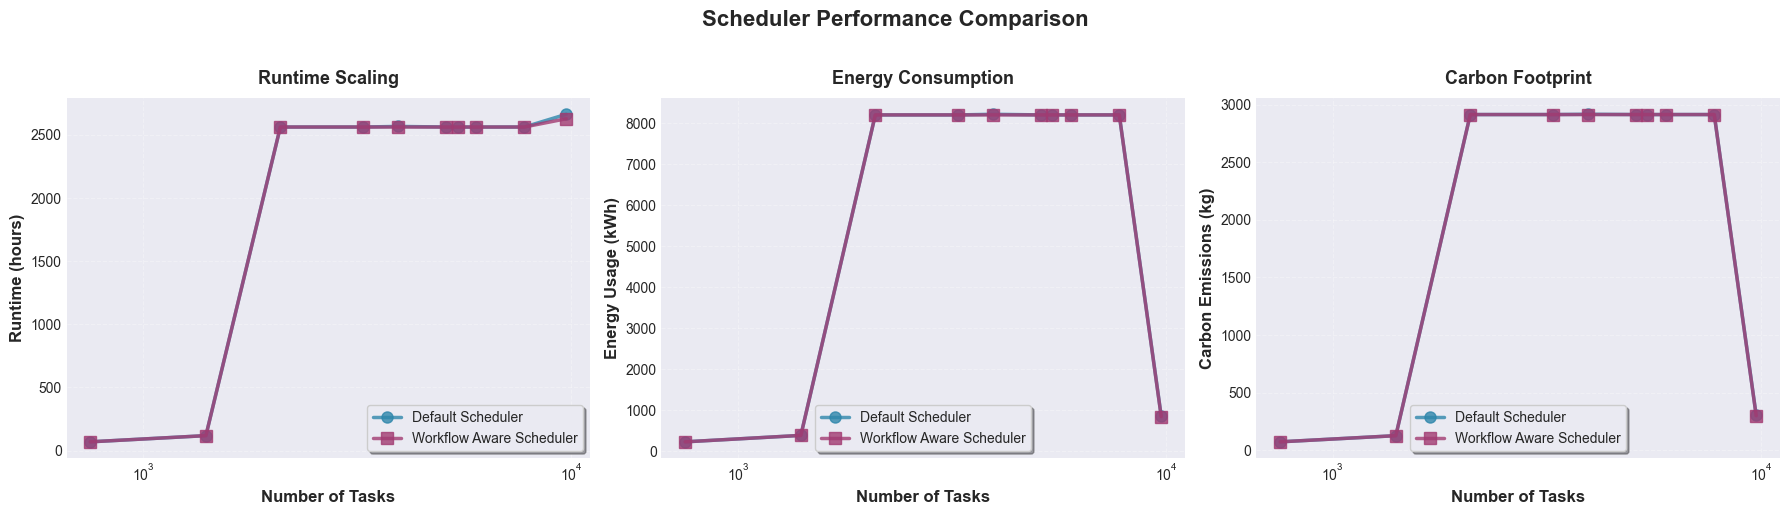

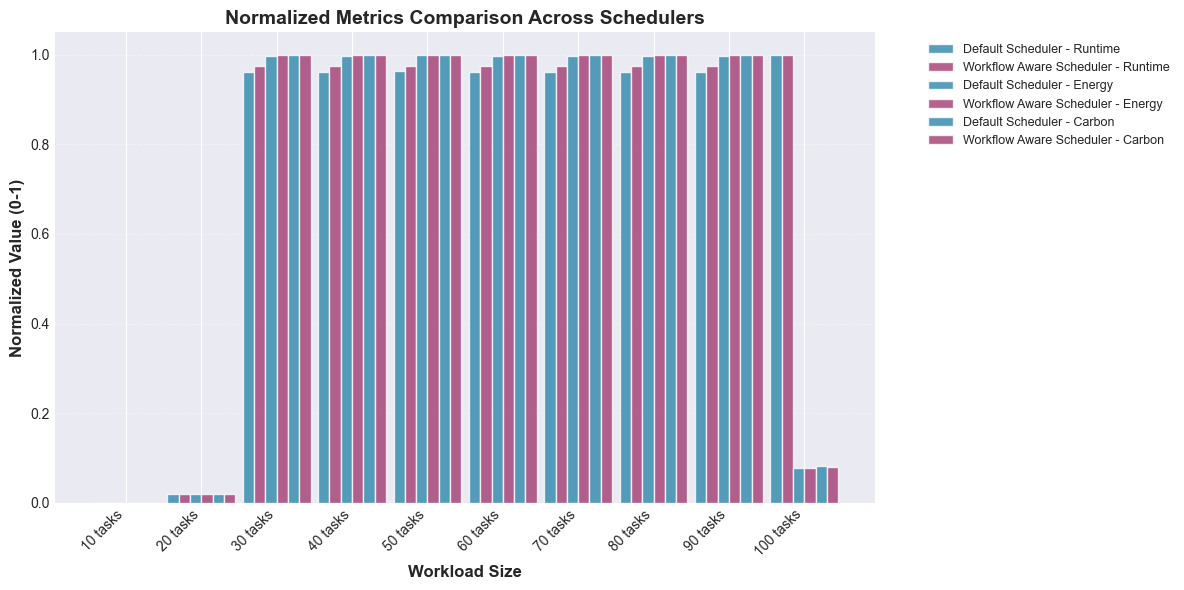

In [48]:
workload_sizes = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
output_path = "output/scaling_experiment/raw-output/{}/seed=0/"

results = {
    "DEFAULT_SCHEDULER": {
        "tasks": [],
        "runtime": [],
        "energy": [],
        "carbon": [],
    },
    "WORKFLOW_AWARE_SCHEDULER": {
        "tasks": [],
        "runtime": [],
        "energy": [],
        "carbon": [],
    },
}


for i in workload_sizes:
    experiment = f"scaling_experiments/scaling_experiment_{i}.json"
    
    # Actual number of tasks in workload
    n_tasks = len(
        pd.read_parquet(f"scaling_workloads/workload_{i}_tasks/tasks.parquet")
    )
    
    # Run experiment
    subprocess.run(
        [
            "../OpenDCExperimentRunner/bin/OpenDCExperimentRunner",
            "--experiment-path",
            experiment,
        ],
        check=True,
    )
    
    # Read outputs per scheduler
    for scheduler_type in SchedulerEnum:
        path = output_path.format(scheduler_type.value)
        df_power = pd.read_parquet(path + "powerSource.parquet")
        df_service = pd.read_parquet(path + "service.parquet")
        
        # Metrics
        runtime_hours = (
            pd.to_timedelta(
                df_service.timestamp.max() - df_service.timestamp.min(),
                unit="ms",
            ).total_seconds()
            / 3600
        )
        energy_kwh = df_power.energy_usage.sum() / 3_600_000
        carbon_kg = df_power.carbon_emission.sum() / 1000
        
        key = scheduler_type.name
        results[key]["tasks"].append(n_tasks)
        results[key]["runtime"].append(runtime_hours)
        results[key]["energy"].append(energy_kwh)
        results[key]["carbon"].append(carbon_kg)

print("SCALING EXPERIMENT RESULTS SUMMARY")
for scheduler, data in results.items():
    print(f"\n{scheduler}")

    
    df_table = pd.DataFrame({
        "Tasks": data["tasks"],
        "Runtime (h)": [f"{x:.2f}" for x in data["runtime"]],
        "Energy (kWh)": [f"{x:.2f}" for x in data["energy"]],
        "Carbon (kg)": [f"{x:.2f}" for x in data["carbon"]],
    })
    
    print(df_table.to_string(index=False))
    print()


print("SCHEDULER COMPARISON (% Difference from DEFAULT)")
if len(results) == 2:
    default_data = results["DEFAULT_SCHEDULER"]
    workflow_data = results["WORKFLOW_AWARE_SCHEDULER"]
    
    comparison = []
    for i in range(len(default_data["tasks"])):
        runtime_diff = ((workflow_data["runtime"][i] - default_data["runtime"][i]) / 
                       default_data["runtime"][i] * 100)
        energy_diff = ((workflow_data["energy"][i] - default_data["energy"][i]) / 
                      default_data["energy"][i] * 100)
        carbon_diff = ((workflow_data["carbon"][i] - default_data["carbon"][i]) / 
                      default_data["carbon"][i] * 100)
        
        comparison.append({
            "Tasks": default_data["tasks"][i],
            "Runtime Δ (%)": f"{runtime_diff:+.1f}",
            "Energy Δ (%)": f"{energy_diff:+.1f}",
            "Carbon Δ (%)": f"{carbon_diff:+.1f}",
        })
    
    df_comparison = pd.DataFrame(comparison)
    print(df_comparison.to_string(index=False))
    print("\nNote: Negative values indicate improvement (reduction)")
    print()

plt.style.use('seaborn-v0_8-darkgrid')
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
markers = ['o', 's', '^', 'D']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Scheduler Performance Comparison', fontsize=16, fontweight='bold', y=1.02)

ax = axes[0]
for idx, (scheduler, data) in enumerate(results.items()):
    label = scheduler.replace('_', ' ').title()
    ax.plot(data["tasks"], data["runtime"], 
            marker=markers[idx], markersize=8, linewidth=2.5, 
            label=label, color=colors[idx], alpha=0.8)
ax.set_xlabel("Number of Tasks", fontsize=12, fontweight='bold')
ax.set_ylabel("Runtime (hours)", fontsize=12, fontweight='bold')
ax.set_title("Runtime Scaling", fontsize=13, fontweight='bold', pad=10)
ax.legend(frameon=True, shadow=True, fontsize=10)
ax.set_xscale("log")
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1]
for idx, (scheduler, data) in enumerate(results.items()):
    label = scheduler.replace('_', ' ').title()
    ax.plot(data["tasks"], data["energy"], 
            marker=markers[idx], markersize=8, linewidth=2.5, 
            label=label, color=colors[idx], alpha=0.8)
ax.set_xlabel("Number of Tasks", fontsize=12, fontweight='bold')
ax.set_ylabel("Energy Usage (kWh)", fontsize=12, fontweight='bold')
ax.set_title("Energy Consumption", fontsize=13, fontweight='bold', pad=10)
ax.legend(frameon=True, shadow=True, fontsize=10)
ax.set_xscale("log")
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[2]
for idx, (scheduler, data) in enumerate(results.items()):
    label = scheduler.replace('_', ' ').title()
    ax.plot(data["tasks"], data["carbon"], 
            marker=markers[idx], markersize=8, linewidth=2.5, 
            label=label, color=colors[idx], alpha=0.8)
ax.set_xlabel("Number of Tasks", fontsize=12, fontweight='bold')
ax.set_ylabel("Carbon Emissions (kg)", fontsize=12, fontweight='bold')
ax.set_title("Carbon Footprint", fontsize=13, fontweight='bold', pad=10)
ax.legend(frameon=True, shadow=True, fontsize=10)
ax.set_xscale("log")
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('scaling_experiment_results.png', dpi=300, bbox_inches='tight')
plt.show()

